In [7]:
import sys
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

import numpy as np
sys.path.append("..")
from smarttrap_tracker import ObjectTrackerYOLO, ParticleCNN
import cv2
%matplotlib inline

In [2]:

def load_z_model( network_name):
    import torch
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    # import types
    orig_load = torch.load

    if device.type == 'cpu':
        model = torch.load(network_name, map_location="cpu",weights_only=False)
        return model

    def _load(*args, **kwargs):
        kwargs.setdefault("weights_only", False)
        return orig_load(*args, **kwargs)

    torch.load = _load
    try:
        return torch.load(network_name)
    except Exception as E:
        print("Could not loadz z-model")
        print(E)
        return None

In [3]:
YOLO_path = "../NeuralNetworks/YOLOV5Weights.pt"
CNN_path = "../NeuralNetworks/Z_model_large_range.pth"
# Load the model
tracker = ObjectTrackerYOLO(YOLO_model_path=YOLO_path, z_model_path=CNN_path, particle_size_limits=[4,200])

# The size limit is widened to allow for detection of both smaller and larger particles than in the original training set.

WARNING requirements: C:\Users\marti\anaconda3\envs\SmartTrap2\Lib\site-packages\yolov5\requirements.txt not found, check failed.


YOLOv5  2025-9-12 Python-3.13.7 torch-2.8.0+cu129 CUDA:0 (NVIDIA GeForce RTX 2070 SUPER, 8192MiB)

c:\Users\marti\anaconda3\envs\SmartTrap2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fusing layers... 
Model summary: 214 layers, 7025023 parameters, 0 gradients, 16.0 GFLOPs
Adding AutoShape... 


Successfully loaded models
Using device: cuda:0


# Analyze an image from the SmartTrap system

C:\Users\marti\anaconda3\envs\SmartTrap2\Lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


[   -0.12629     0.10703     0.55776]


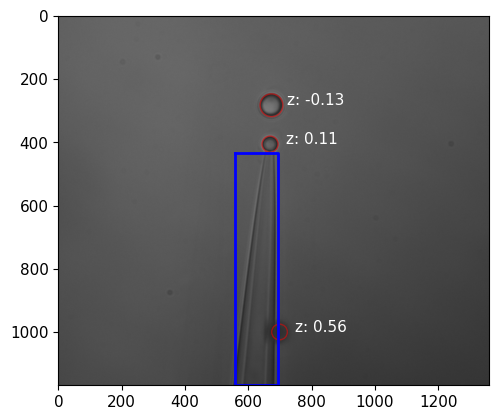

In [11]:
# Path to your AVI file
image = cv2.imread("Example data/ExampleImageSmartTrap.png")
fig, ax = plt.subplots()


tracker.analyze_frame(image)
positions = tracker.predict_particle_positions()
z_positions = tracker.predict_z_positions(image[:,:,0], positions[0])

print(z_positions)
plt.imshow(image)

for pos, size, z in zip(positions[0],positions[1],z_positions):    
    circle = Circle((pos[0], pos[1]), radius=size, fill=False, color='r',alpha=0.5)
    
    ax.add_patch(circle)
    ax.text(pos[0]+50, pos[1], f"z: {z:.2f}", color='white')

PL = tracker.predict_pipette_position()
x = PL[0][0]-PL[0][2]/2
y = PL[0][1]
w = PL[0][2]
h = PL[0][3]
xs = [x, x+w, x+w, x, x]
ys = [y, y, y+h, y+h, y]
plt.plot(xs, ys, color='blue', linewidth=2)

plt.show()


# Analyze an image of multiple 2 micron MF particles

C:\Users\marti\anaconda3\envs\SmartTrap2\Lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


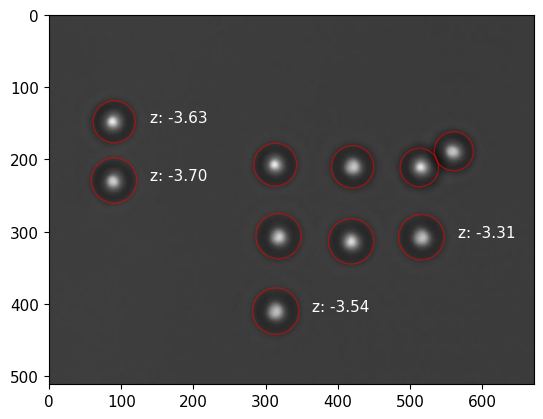

In [ ]:
image = cv2.imread("Example data/ExampleImageSilica.png")
fig, ax = plt.subplots()


tracker.analyze_frame(image)
positions = tracker.predict_particle_positions()
z_positions = tracker.predict_z_positions(image[:,:,0], positions[0])

plt.imshow(image)
nbr_particles = 0
particle_indices = [1,4,5,6]

for pos, size, z in zip(positions[0],positions[1],z_positions):    
    circle = Circle((pos[0], pos[1]), radius=size, fill=False, color='r',alpha=0.5)
    nbr_particles += 1
    ax.add_patch(circle)
    # Uncomment this to show the z-predictions
    if nbr_particles in particle_indices:
        ax.text(pos[0]+50, pos[1], f"z: {z:.2f}", color='white')

ax.set_aspect('equal')

# Analyze image of MF particles

C:\Users\marti\anaconda3\envs\SmartTrap2\Lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


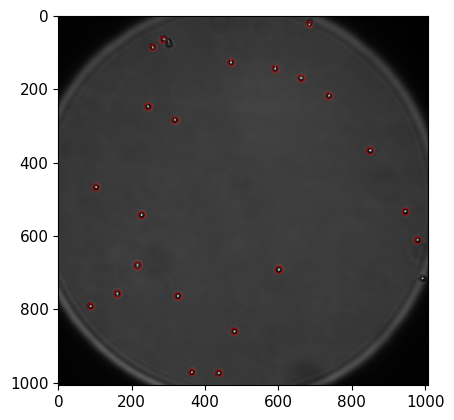

In [ ]:
image = cv2.imread("Example data/ExampleImageMF.png")
fig, ax = plt.subplots()


tracker.analyze_frame(image)
positions = tracker.predict_particle_positions()
z_positions = tracker.predict_z_positions(image[:,:,0], positions[0])

plt.imshow(image)
for pos, size, z in zip(positions[0],positions[1],z_positions):    
    circle = Circle((pos[0], pos[1]), radius=size, fill=False, color='r',alpha=0.5)
    
    ax.add_patch(circle)
    # Uncomment this to show the z-predictions
    # Not very reliable for these small particles very different from training data
    # ax.text(pos[0]+50, pos[1], f"z: {z:.2f}", color='white')
ax.set_aspect('equal')  # so circles aren't stretched
